# 4.3.1	Effects on the Removal of ECA

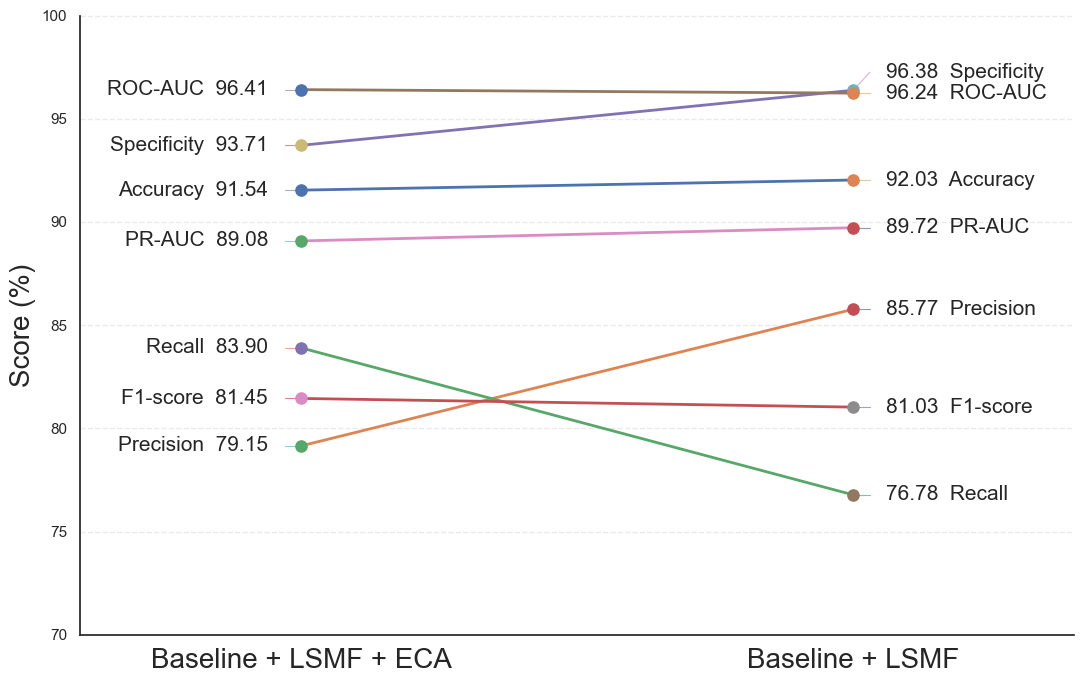

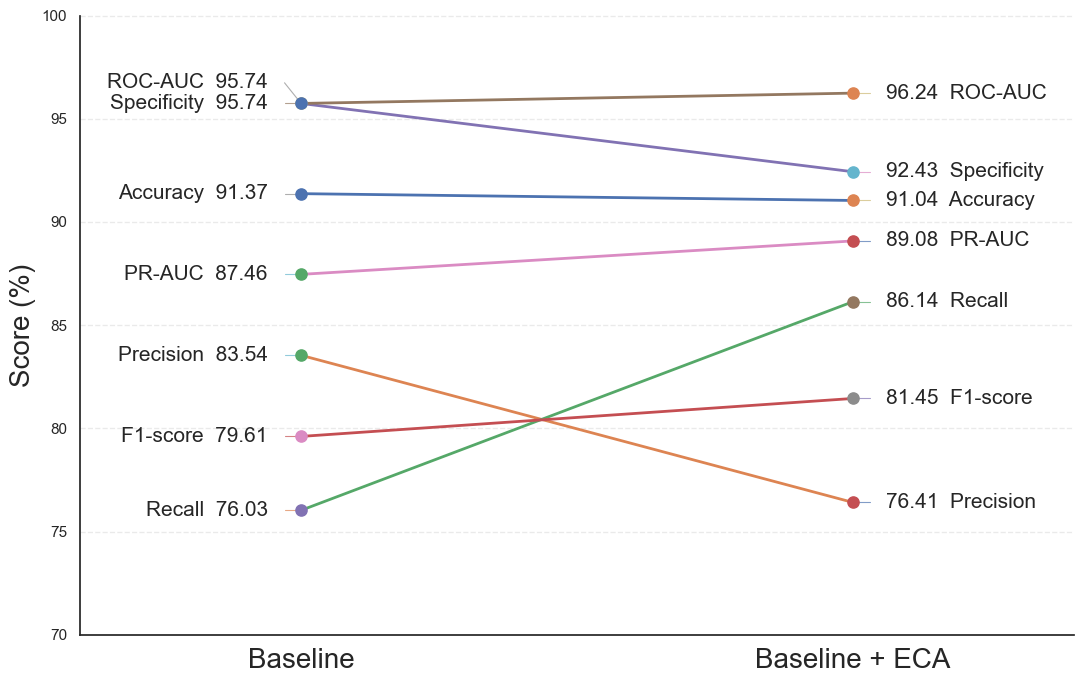

In [36]:
import matplotlib.pyplot as plt

# =========================
# 1. Data
# =========================
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity", "ROC-AUC", "PR-AUC"]

# Effect of removing ECA under LSMF setting
before_remove_eca = [91.54, 79.15, 83.90, 81.45, 93.71, 96.41, 89.08]   # Baseline + LSMF + ECA
after_remove_eca  = [92.03, 85.77, 76.78, 81.03, 96.38, 96.24, 89.72]   # Baseline + LSMF

# Effect of adding ECA under baseline setting
before_add_eca = [91.37, 83.54, 76.03, 79.61, 95.74, 95.74, 87.46]       # Baseline
after_add_eca  = [91.04, 76.41, 86.14, 81.45, 92.43, 96.24, 89.08]       # Baseline + ECA


# =========================
# 2. Helper: adjust label positions
# =========================
def adjust_positions(values, min_gap=1.2):
    """
    Make nearby text labels vertically separated.
    """
    pairs = sorted(enumerate(values), key=lambda x: x[1])
    adjusted = [0] * len(values)

    prev_y = None
    for idx, y in pairs:
        new_y = y
        if prev_y is not None and new_y - prev_y < min_gap:
            new_y = prev_y + min_gap
        adjusted[idx] = new_y
        prev_y = new_y

    return adjusted


# =========================
# 3. Slope chart function
# =========================
def plot_slope_chart(metrics, left_values, right_values, left_label, right_label, title, save_name=None):
    fig, ax = plt.subplots(figsize=(11, 7))

    x_left = 0
    x_right = 1

    # line + points
    for i, metric in enumerate(metrics):
        y1 = left_values[i]
        y2 = right_values[i]

        ax.plot([x_left, x_right], [y1, y2], linewidth=2)
        ax.scatter(x_left, y1, s=65, zorder=3)
        ax.scatter(x_right, y2, s=65, zorder=3)

    # adjusted label positions
    left_text_y = adjust_positions(left_values, min_gap=1.0)
    right_text_y = adjust_positions(right_values, min_gap=1.0)

    # connector lines from points to labels
    for i, metric in enumerate(metrics):
        y1 = left_values[i]
        y2 = right_values[i]
        ty1 = left_text_y[i]
        ty2 = right_text_y[i]

        # thin connector line
        ax.plot([x_left, x_left - 0.03], [y1, ty1], linewidth=0.8, alpha=0.7)
        ax.plot([x_right, x_right + 0.03], [y2, ty2], linewidth=0.8, alpha=0.7)

        # left label
        ax.text(
            x_left - 0.06, ty1,
            f"{metric}  {y1:.2f}",
            ha='right', va='center', fontsize=15
        )

        # right label
        ax.text(
            x_right + 0.06, ty2,
            f"{y2:.2f}  {metric}",
            ha='left', va='center', fontsize=15
        )

    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([left_label, right_label], fontsize=20)

    ax.set_title(title, fontsize=20)
    ax.set_ylabel("Score (%)", fontsize=20)
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(70, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=600, bbox_inches="tight")

    plt.show()


# =========================
# 4. Figure 1: Removing ECA
# =========================
plot_slope_chart(
    metrics,
    before_remove_eca,
    after_remove_eca,
    "Baseline + LSMF + ECA",
    "Baseline + LSMF",
    # "Effect of Removing ECA under the LSMF Setting",
    None,
    save_name="slope_remove_eca_lsmf_no_overlap.png"
)


# =========================
# 5. Figure 2: Adding ECA
# =========================
plot_slope_chart(
    metrics,
    before_add_eca,
    after_add_eca,
    "Baseline",
    "Baseline + ECA",
    # "Effect of Adding ECA under the Baseline Setting",
    None,
    save_name="slope_add_eca_baseline_no_overlap.png"
)

# 4.3.2	Effects on the Removal of LSMF

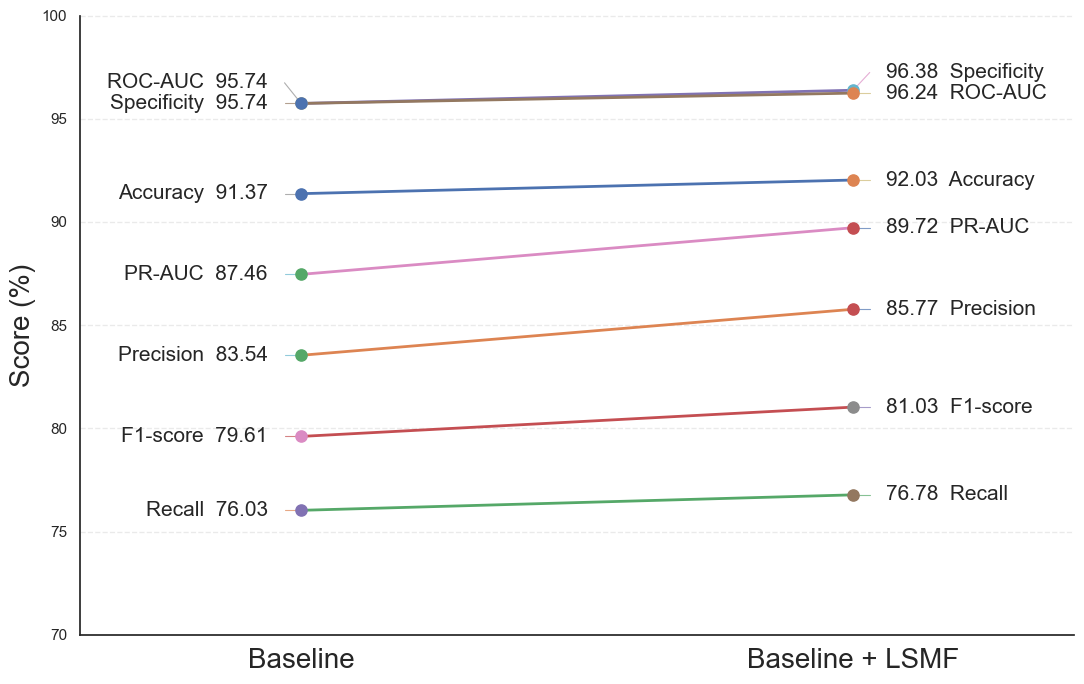

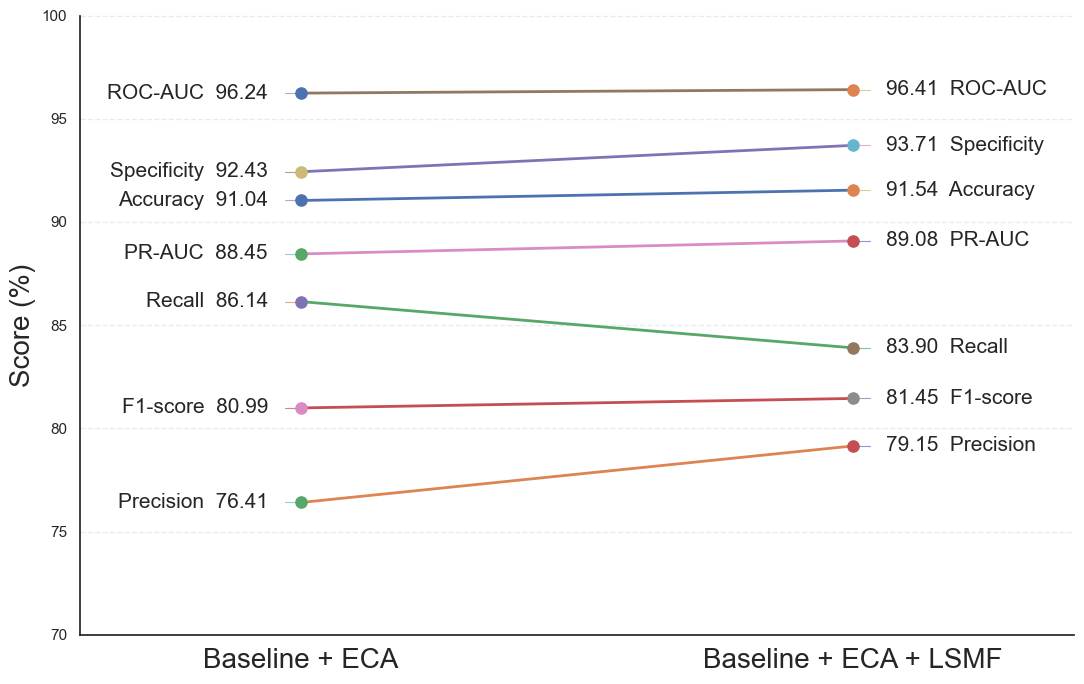

In [37]:
import matplotlib.pyplot as plt

# =========================
# 1. Data
# =========================
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity", "ROC-AUC", "PR-AUC"]

# Figure 1: Effect of adding LSMF to Baseline
baseline = [91.37, 83.54, 76.03, 79.61, 95.74, 95.74, 87.46]
baseline_lsmf = [92.03, 85.77, 76.78, 81.03, 96.38, 96.24, 89.72]

# Figure 2: Effect of adding LSMF to Baseline + ECA
baseline_eca = [91.04, 76.41, 86.14, 80.99, 92.43, 96.24, 88.45]
baseline_eca_lsmf = [91.54, 79.15, 83.90, 81.45, 93.71, 96.41, 89.08]


# =========================
# 2. Helper: avoid text overlap
# =========================
def adjust_positions(values, min_gap=1.0):
    pairs = sorted(enumerate(values), key=lambda x: x[1])
    adjusted = [0] * len(values)

    prev_y = None
    for idx, y in pairs:
        new_y = y
        if prev_y is not None and new_y - prev_y < min_gap:
            new_y = prev_y + min_gap
        adjusted[idx] = new_y
        prev_y = new_y

    return adjusted


# =========================
# 3. Slope chart function
# =========================
def plot_slope_chart(metrics, left_values, right_values, left_label, right_label, title, save_name=None):
    fig, ax = plt.subplots(figsize=(11, 7))

    x_left = 0
    x_right = 1

    # lines and points
    for i in range(len(metrics)):
        y1 = left_values[i]
        y2 = right_values[i]

        ax.plot([x_left, x_right], [y1, y2], linewidth=2)
        ax.scatter(x_left, y1, s=65, zorder=3)
        ax.scatter(x_right, y2, s=65, zorder=3)

    # adjusted label positions
    left_text_y = adjust_positions(left_values, min_gap=1.0)
    right_text_y = adjust_positions(right_values, min_gap=1.0)

    # connectors + labels
    for i, metric in enumerate(metrics):
        y1 = left_values[i]
        y2 = right_values[i]
        ty1 = left_text_y[i]
        ty2 = right_text_y[i]

        ax.plot([x_left, x_left - 0.03], [y1, ty1], linewidth=0.8, alpha=0.7)
        ax.plot([x_right, x_right + 0.03], [y2, ty2], linewidth=0.8, alpha=0.7)

        ax.text(
            x_left - 0.06, ty1,
            f"{metric}  {y1:.2f}",
            ha='right', va='center', fontsize=15
        )

        ax.text(
            x_right + 0.06, ty2,
            f"{y2:.2f}  {metric}",
            ha='left', va='center', fontsize=15
        )

    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([left_label, right_label], fontsize=20)

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Score (%)", fontsize=20)
    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(70, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=600, bbox_inches="tight")

    plt.show()


# =========================
# 4. Figure 1
# =========================
plot_slope_chart(
    metrics,
    baseline,
    baseline_lsmf,
    "Baseline",
    "Baseline + LSMF",
    # "Effect of Adding LSMF to the Baseline Variant",
    None,
    save_name="slope_add_lsmf_baseline.png"
)


# =========================
# 5. Figure 2
# =========================
plot_slope_chart(
    metrics,
    baseline_eca,
    baseline_eca_lsmf,
    "Baseline + ECA",
    "Baseline + ECA + LSMF",
    # "Effect of Adding LSMF to the ECA Variant",
    None,
    save_name="slope_add_lsmf_eca.png"
)

# 4.3	Ablation Study Results

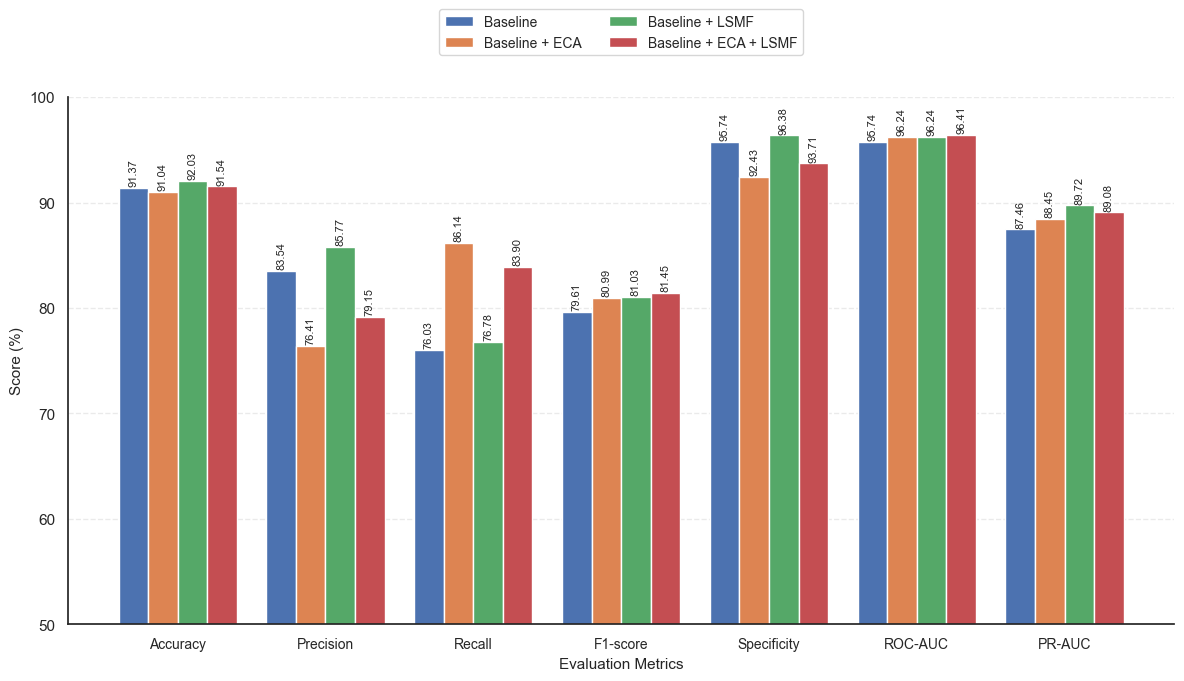

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Data
# =========================
metrics = [
    "Accuracy", "Precision", "Recall", "F1-score",
    "Specificity", "ROC-AUC", "PR-AUC"
]

baseline = [91.37, 83.54, 76.03, 79.61, 95.74, 95.74, 87.46]
baseline_eca = [91.04, 76.41, 86.14, 80.99, 92.43, 96.24, 88.45]
baseline_lsmf = [92.03, 85.77, 76.78, 81.03, 96.38, 96.24, 89.72]
baseline_eca_lsmf = [91.54, 79.15, 83.90, 81.45, 93.71, 96.41, 89.08]

# =========================
# 2. Plot settings
# =========================
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - 1.5 * width, baseline, width, label="Baseline")
bars2 = ax.bar(x - 0.5 * width, baseline_eca, width, label="Baseline + ECA")
bars3 = ax.bar(x + 0.5 * width, baseline_lsmf, width, label="Baseline + LSMF")
bars4 = ax.bar(x + 1.5 * width, baseline_eca_lsmf, width, label="Baseline + ECA + LSMF")

# =========================
# 3. Add value labels
# =========================
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.15,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# =========================
# 4. Styling
# =========================
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_xlabel("Evaluation Metrics", fontsize=11)
# ax.set_title("Internal Test Performance Comparison Across Four Variants", fontsize=13, pad=12)

ax.set_ylim(50, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.savefig("four_model_grouped_bar_chart.png", dpi=600, bbox_inches="tight")
plt.show()

# 4.2.2	Comparison on External Generalization Set

In [39]:
# import numpy as np
# import matplotlib.pyplot as plt

# # =========================
# # External test set results
# # =========================
# metrics = ["Acc", "Prec", "Rec", "F1", "Spec", "ROC-AUC", "PR-AUC"]

# data = {
#     "Baseline": [76.19, 95.20, 55.15, 69.84, 97.22, 86.05, 88.38],
#     "Baseline + ECA": [80.90, 84.70, 75.43, 79.80, 86.37, 87.38, 89.21],
#     "Baseline + LSMF": [76.16, 95.85, 54.69, 69.65, 97.63, 86.09, 88.48],
#     "Baseline + ECA + LSMF": [77.48, 93.70, 58.93, 72.36, 96.03, 85.84, 88.45],
# }

# model_names = list(data.keys())

# # =========================
# # Radar chart setup
# # =========================
# N = len(metrics)
# angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
# angles_closed = np.concatenate([angles, [angles[0]]])

# fig = plt.figure(figsize=(16, 8))

# # 左边：雷达图
# ax = fig.add_subplot(1, 2, 1, polar=True)

# for model_name, values in data.items():
#     values = np.array(values)
#     values_closed = np.concatenate([values, [values[0]]])
#     ax.plot(angles_closed, values_closed, linewidth=2, label=model_name)
#     ax.fill(angles_closed, values_closed, alpha=0.06)
#     ax.scatter(angles, values, s=28, zorder=3)

# ax.set_xticks(angles)
# ax.set_xticklabels(metrics, fontsize=11)
# ax.set_ylim(50, 100)
# ax.set_yticks([60, 70, 80, 90, 100])
# ax.set_yticklabels(["60", "70", "80", "90", "100"], fontsize=10)

# # ax.set_title("Performance Radar Chart on the External Test Set", fontsize=13, pad=20)

# ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10, frameon=True)

# ax2 = fig.add_subplot(1, 2, 2)
# ax2.axis("off")

# ax2.text(
#     0.02, 0.98,
#     "Metric Values (%)",
#     fontsize=14,
#     fontweight="bold",
#     va="top"
# )

# start_y = 0.90
# block_gap = 0.125

# for i, metric in enumerate(metrics):
#     y = start_y - i * block_gap

#     block_text = (
#         f"{metric}\n"
#         f"Baseline: {data['Baseline'][i]:.2f}\n"
#         f"Baseline + ECA: {data['Baseline + ECA'][i]:.2f}\n"
#         f"Baseline + LSMF: {data['Baseline + LSMF'][i]:.2f}\n"
#         f"Baseline + ECA + LSMF: {data['Baseline + ECA + LSMF'][i]:.2f}"
#     )

#     ax2.text(
#         0.02, y, block_text,
#         fontsize=10,
#         va="top",
#         ha="left",
#         bbox=dict(
#             boxstyle="round,pad=0.35",
#             facecolor="white",
#             edgecolor="gray",
#             alpha=0.95
#         )
#     )

# plt.tight_layout()
# plt.savefig("external_radar_with_value_panel.png", dpi=600, bbox_inches="tight")
# plt.show()

# 4.2.2	Comparison on External Generalization Set

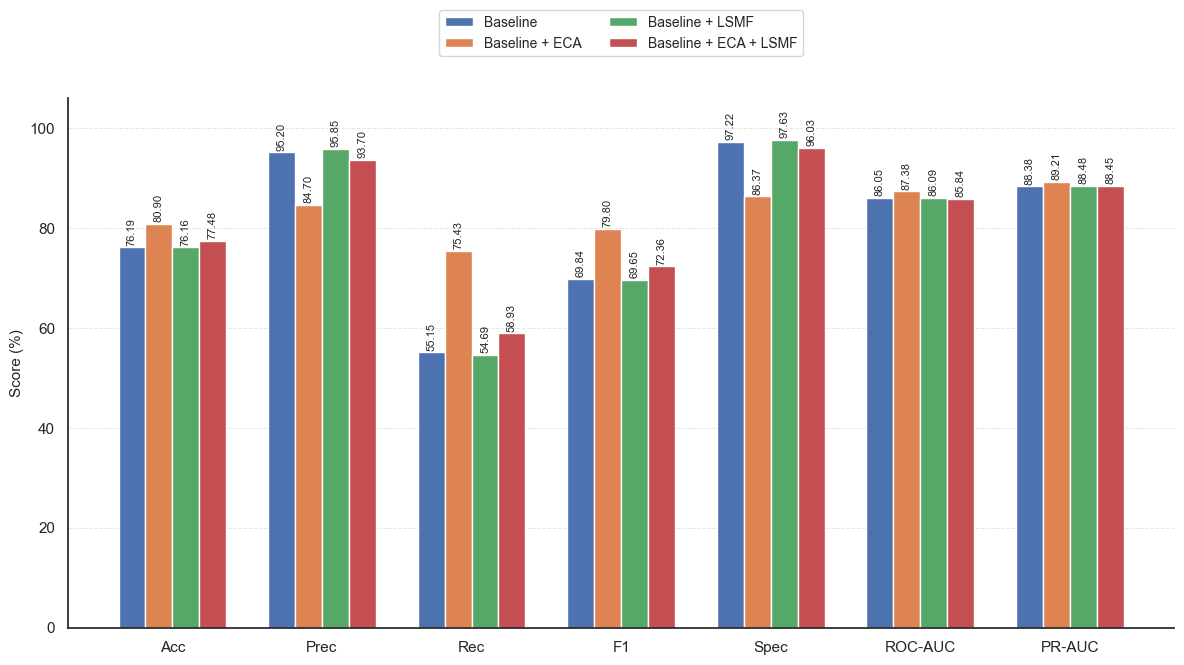

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================
metrics = ["Acc", "Prec", "Rec", "F1", "Spec", "ROC-AUC", "PR-AUC"]

baseline = [76.19, 95.20, 55.15, 69.84, 97.22, 86.05, 88.38]
baseline_eca = [80.90, 84.70, 75.43, 79.80, 86.37, 87.38, 89.21]
baseline_lsmf = [76.16, 95.85, 54.69, 69.65, 97.63, 86.09, 88.48]
baseline_eca_lsmf = [77.48, 93.70, 58.93, 72.36, 96.03, 85.84, 88.45]

# =========================
# Layout
# =========================
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6.8))

bars1 = ax.bar(x - 1.5 * width, baseline, width, label="Baseline")
bars2 = ax.bar(x - 0.5 * width, baseline_eca, width, label="Baseline + ECA")
bars3 = ax.bar(x + 0.5 * width, baseline_lsmf, width, label="Baseline + LSMF")
bars4 = ax.bar(x + 1.5 * width, baseline_eca_lsmf, width, label="Baseline + ECA + LSMF")

# =========================
# Value labels
# =========================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.35,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# =========================
# Formatting
# =========================
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, 106)
ax.set_title("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.5)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.savefig("external_grouped_barchart.png", dpi=600, bbox_inches="tight")
plt.show()

# Pr Loss

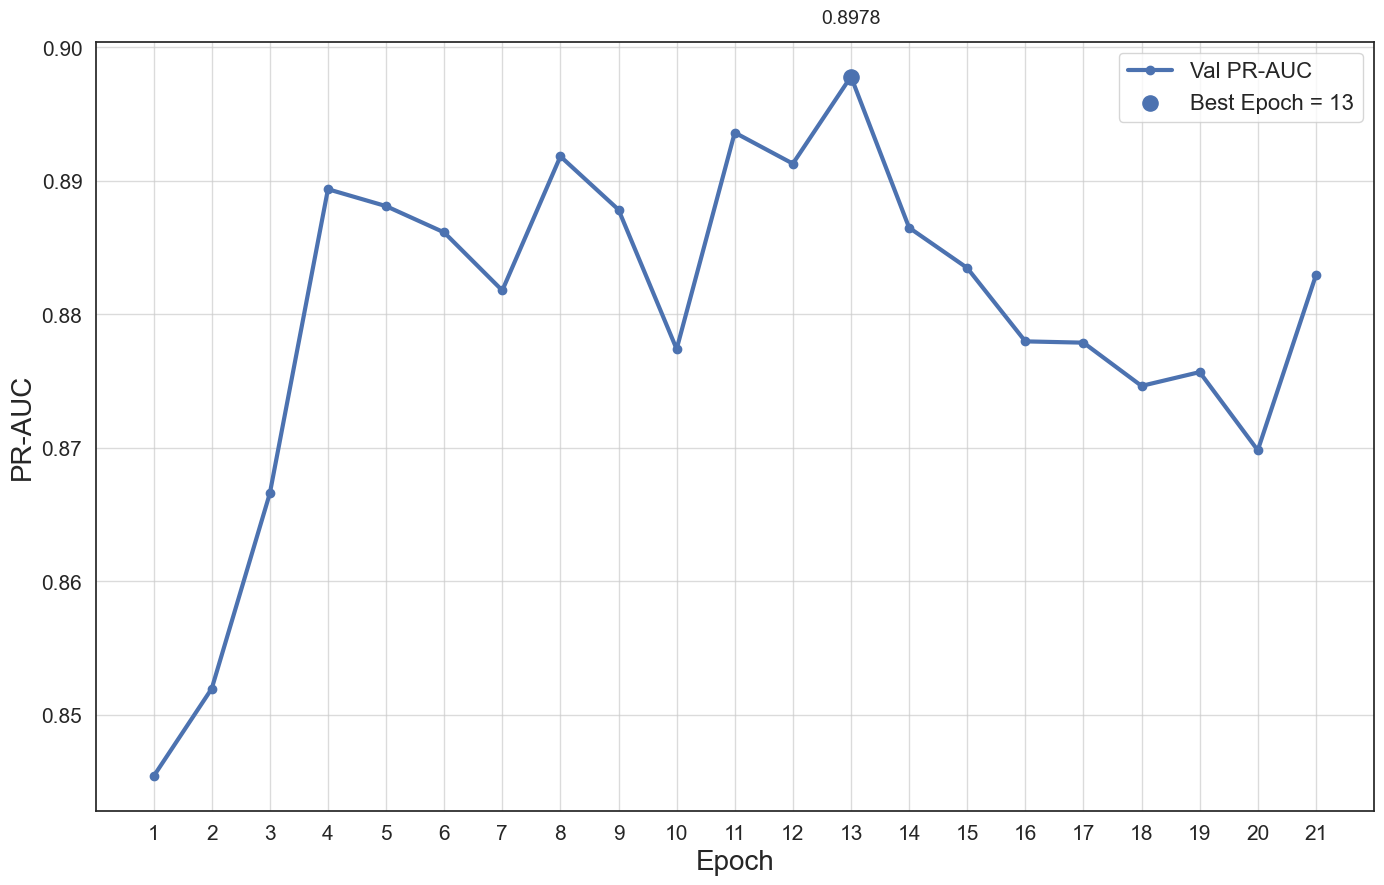

In [48]:
import matplotlib.pyplot as plt

epochs = list(range(1, 22))
val_pr = [
    0.8454052904377142,
    0.8519698779062965,
    0.8665989111319940,
    0.8893818829934191,
    0.8881145501273770,
    0.8861440087992393,
    0.8817960545499399,
    0.8918429395641687,
    0.8878464818326092,
    0.8774056070439055,
    0.8936230763204528,
    0.8912954618183442,
    0.8978205746563678,
    0.8865021128370888,
    0.8834843369193476,
    0.8779832608239782,
    0.8778863261650947,
    0.8746470368043140,
    0.8756812689444683,
    0.8698259551937655,
    0.8829280416235863,
]

best_val = max(val_pr)
best_epoch = epochs[val_pr.index(best_val)]

plt.figure(figsize=(14, 9))
plt.plot(epochs, val_pr, marker='o', linewidth=3, label='Val PR-AUC')
plt.scatter(best_epoch, best_val, s=120, label=f'Best Epoch = {best_epoch}')
plt.annotate(
    f'{best_val:.4f}',
    xy=(best_epoch, best_val),
    xytext=(best_epoch, best_val + 0.004),
    ha='center',
    fontsize=14
)

# plt.title('Validation PR-AUC of the Baseline + LSMF Variant', fontsize=24)
plt.xlabel('Epoch', fontsize=20)
plt.ylabel('PR-AUC', fontsize=20)
plt.xticks(epochs, fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.savefig("val_pr_auc_trend.png", dpi=600, bbox_inches="tight")
plt.show()